# Data Demo

This notebook shows a few examples from the dataset class used by the project.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import torch
from matplotlib import pyplot as plt
from pm.dataset.dataloader import LABEL_TO_ID, get_data_loaders
from pm.model import AudioClassifier

id_to_label = {v: k for k, v in LABEL_TO_ID.items()}

In [2]:
loader = get_data_loaders(batch_size=4, name="example")
spectrograms, labels = next(iter(loader))

print("spectrogram batch:", tuple(spectrograms.shape))
print("labels:", [id_to_label[int(label)] for label in labels])

spectrogram batch: (4, 1, 96, 201)
labels: ['fake', 'real', 'fake', 'real']


## Spectrogram Examples

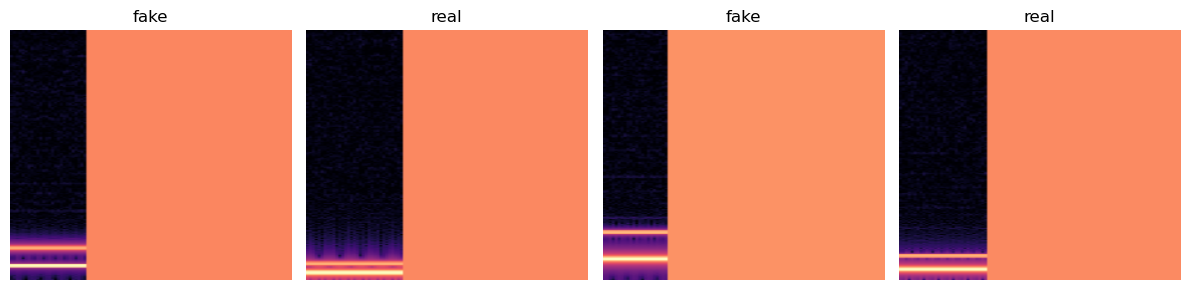

In [3]:
plot_specs = [spec.T for spec in spectrograms.squeeze(1).numpy()]
fig, axes = plt.subplots(1, len(plot_specs), figsize=(12, 3))
axes = np.atleast_1d(axes)

for index, ax in enumerate(axes):
    ax.imshow(plot_specs[index], aspect="auto", origin="lower", cmap="magma")
    ax.set_title(id_to_label[int(labels[index])])
    ax.axis("off")

plt.tight_layout()
(repo_root / "assets").mkdir(exist_ok=True)
plt.savefig(repo_root / "assets/train_batch.png", dpi=150)
plt.show()

## Model Shape Check

In [4]:
model = AudioClassifier(num_classes=2)
logits = model(spectrograms)
print("model output:", tuple(logits.shape))

model output: (4, 2)
